# Dependencies

In [1]:
%run start.py

Root set to: /home/bdudas/obesity_challange


In [25]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
plt.style.use('ggplot')

In [3]:
dataroot = "data"
h5data = "obesity_challenge_1"
obdata = ad.read_h5ad(f"{dataroot}/{h5data}.h5ad")

gene_names = obdata.var.index.to_numpy()
#gene_to_idx = {g: i for i, g in enumerate(obdata.var.index.unique().to_numpy())}
#gene_to_idx["NC"] = -1
gene_to_idx = {g: i for i, g in enumerate(obdata.obs.gene.unique().to_numpy())}
gene_name_to_idx = {g: i for i, g in enumerate(gene_names)}
idx_to_gene = {i: g for g, i in gene_to_idx.items()}

In [4]:
perts = "predict_perturbations.txt"
perturbs = np.loadtxt(f"{dataroot}/{perts}",dtype =str)
perturbs.shape

(2863,)

# Data Exploration

In [5]:
obdata.obs.num_umis.min(),obdata.obs.num_umis.max()

(5, 2559)

In [6]:
obdata.obs.describe()

,nCount_RNA,nFeature_RNA,nCount_guide,nFeature_guide,percent.mt,num_features,num_umis,adipo,pre_adipo,other,lipo
count,88202.000000,88202.000000,88202.000000,88202.000000,88202.000000,88202.0,88202.000000,88202.000000,88202.000000,88202.000000,88202.000000
mean,72566.805696,7977.031088,204.177377,5.880332,4.361195,1.0,199.142298,0.274007,0.373801,0.352192,0.080157
std,19693.090903,939.481688,108.772184,3.086354,1.652693,0.0,108.463391,0.446015,0.483815,0.477656,0.271538
min,515.000000,371.000000,8.000000,1.000000,0.034116,1.0,5.000000,0.000000,0.000000,0.000000,0.000000
25%,60846.000000,7589.000000,131.000000,4.000000,3.268167,1.0,126.000000,0.000000,0.000000,0.000000,0.000000
50%,70295.000000,8046.000000,191.000000,5.000000,4.153869,1.0,186.000000,0.000000,0.000000,0.000000,0.000000
75%,82140.000000,8496.000000,262.000000,7.000000,5.202373,1.0,257.000000,1.000000,1.000000,1.000000,0.000000
max,196008.000000,11964.000000,2567.000000,76.000000,14.930792,1.0,2559.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
obdata.X.shape

(88202, 21592)

In [8]:
obdata.X[0].toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 4.34418824,
        0.        ]])

In [9]:
sum(obdata.obs.gene == "NC")

8705

<Axes: ylabel='Density'>

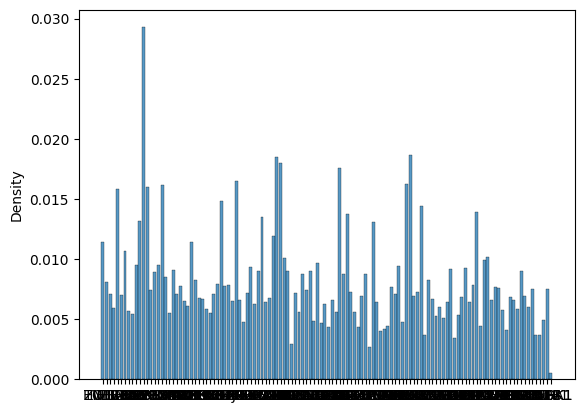

In [10]:
sns.histplot(x= obdata.obs.gene[obdata.obs.gene != "NC"].to_numpy(), stat ="density", shrink = 0.8)

In [11]:

gene_to_idx["NC"]

9

In [27]:
baseline_data = obdata[obdata.obs.gene == "NC"].X.toarray()

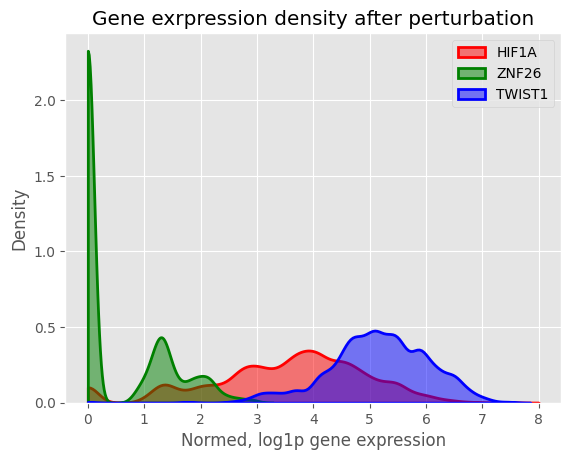

In [26]:
sampleGene1 = obdata.obs.gene.iloc[0]
geneidx1 = gene_name_to_idx[sampleGene1]
geneData1 =obdata[obdata.obs.gene == sampleGene1].X.toarray()

sampleGene2 = obdata.obs.gene.iloc[1]
geneidx2 = gene_name_to_idx[sampleGene2]
geneData2 =obdata[obdata.obs.gene == sampleGene2].X.toarray()

sampleGene3 = obdata.obs.gene.iloc[2]
geneidx3 = gene_name_to_idx[sampleGene3]
geneData3 =obdata[obdata.obs.gene == sampleGene3].X.toarray()

plt.title('Gene exrpression density after perturbation')
plt.xlabel('Normed, log1p gene expression')
sns.kdeplot(geneData1[:,geneidx1], fill = True, alpha = 0.5, label = sampleGene1, color = "red", linewidth = 2, bw_adjust = 0.5, clip = (0, None))
sns.kdeplot(geneData2[:,geneidx2], fill = True, alpha = 0.5, label = sampleGene2, color = "green", linewidth = 2, bw_adjust = 0.5, clip = (0, None))
sns.kdeplot(geneData3[:,geneidx3], fill = True, alpha = 0.5, label = sampleGene3, color = "blue", linewidth = 2, bw_adjust = 0.5, clip = (0, None))
plt.legend()


In [31]:
gdatas = [geneData1,geneData2,geneData3]
gdataidxs = [geneidx1,geneidx2,geneidx3]
samplegenes = [sampleGene1,sampleGene2,sampleGene3]

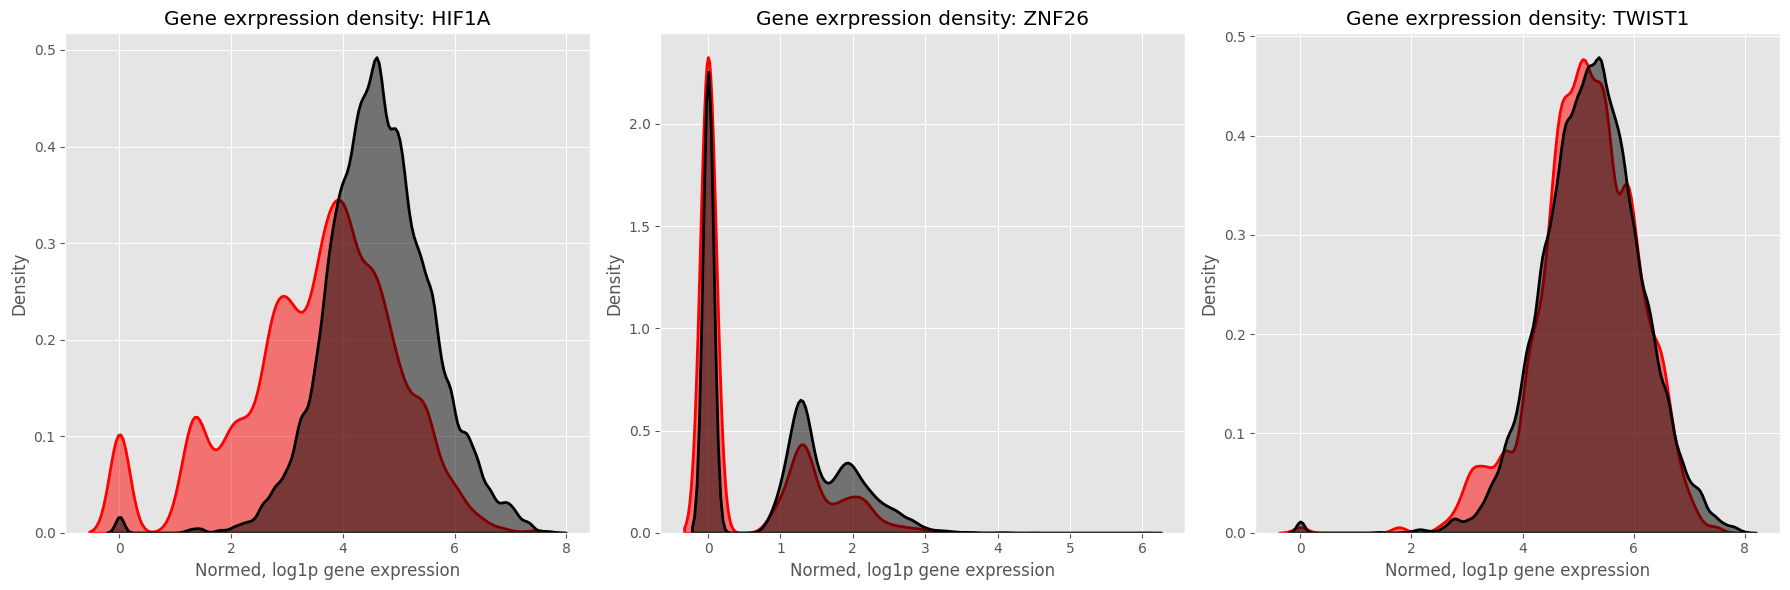

In [35]:
plt.figure(figsize=(18,6))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.title(f'Gene exrpression density: {obdata.obs.gene.iloc[i]}')
    plt.xlabel('Normed, log1p gene expression')
    sns.kdeplot(gdatas[i][:,gdataidxs[i]], fill = True, alpha = 0.5, label = samplegenes[i], color = "red", linewidth = 2, bw_adjust = 0.5, )
    sns.kdeplot(baseline_data[:,gdataidxs[i]], fill = True, alpha = 0.5, label = "Baseline NC", color = "black", linewidth = 2, bw_adjust = 0.5)
plt.tight_layout()

**Problem 1**: Does perturbation mean we convert values of a certain expression to 0? Because it seems it's not happening in this dataset.   

**Problem 2**: Standard normalization is $\frac{X-\mu}{\sigma}$, while division with $\sigma$ does not affect the values of 0, $\mu$ should affect it. Especially since our data can be only over 0 in the counts -> $\mu >= 0$. 



# Creating Dataset

In [37]:
class CellDataset():
    def __init__(self,adataTarget, gene_to_idx,seq_length:int = 32):
        self.adata = adataTarget
        self.gene_to_idx = gene_to_idx
        self.seq_length = seq_length
    def __len__(self):
        return self.adata.X.shape[0]

    def __getitem__(self,idx):
        x = np.concatenate([self.adata.X[idx].toarray().ravel(), [0,0,0,0,0,0,0,0]],dtype = np.float32) # Extra padding to have nice sequences
        gene = self.adata.obs.gene.iloc[idx]
        gene = self.gene_to_idx[gene]
        state = self.adata.obs.iloc[idx,[-1,-2,-3,-4]].to_numpy(dtype=np.int32)
        return x.reshape(self.seq_length,-1), gene, state

In [39]:
dataset = CellDataset(obdata, gene_to_idx)

loader = torch.utils.data.DataLoader(dataset, batch_size = 32,shuffle= True)
traiset,valset = torch.utils.data.random_split(dataset, [int(0.8*len(dataset)), len(dataset)-int(0.8*len(dataset))])
trainloader = torch.utils.data.DataLoader(traiset, batch_size = 32,shuffle= True,)
valloader = torch.utils.data.DataLoader(valset, batch_size = 32,shuffle= False)

In [109]:
Xs, genes, state = next(iter(loader))
Xs.shape, genes.shape, state.shape

(torch.Size([32, 32, 675]), torch.Size([32]), torch.Size([32, 4]))

In [110]:
tmp = obdata.X[0].toarray()
np.sum(tmp != 0 )

np.int64(8463)

Information about the targeting vs non-targeting distribution inside the data. Around 10% of training samples are coming from the targeting data.

In [60]:
obdata.obs[obdata.obs.gene == "NC"].shape[0], obdata.obs[obdata.obs.gene != "NC"].shape[0], obdata.obs.shape[0]/obdata.obs[obdata.obs.gene == "NC"].shape[0]

(8705, 79497, 10.132337736932797)

In [61]:
Xs.shape

torch.Size([32, 32, 675])

In [62]:
genes

tensor([   -1,  3033,    -1,   648, 12928,  8852,  4890,  3421, 15471,  1635,
        17900, 12928,  4890, 11987,   870,  1216,   648,  8540, 10827,    -1,
        10146,  7559, 13683, 11153, 10672, 18148,    -1,  8852, 16683, 13683,
         9652,  3033])

# Learning categories

In [53]:
import pytorch_lightning as pl
import torch.nn as nn

c:\Users\bence\miniconda3\envs\vcell\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
Xs.dtype

torch.float64

In [ ]:
nn.Embedding()

In [78]:
encoder_layer = nn.TransformerEncoderLayer(d_model=675, nhead=5,batch_first=True)
transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=5)
## Replace it with a BERT encoder or something similar


out = transformer_encoder(Xs)

c:\Users\bence\miniconda3\envs\vcell\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


In [77]:
out.shape

torch.Size([32, 32, 675])

In [84]:
class TransformerVAEEncoder(nn.Module):
    def __init__(self, input_dim=675, d_model=512, n_layers=6, n_heads=8, z_dim=32):
        super().__init__()

        self.token_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, n_layers)

        self.mu = nn.Linear(d_model, z_dim)
        self.logvar = nn.Linear(d_model, z_dim)

    def forward(self, x):
        # x: (B, 32, 675)
        h = self.token_proj(x)
        h = self.encoder(h)
        # Optionally add layernorm here
        h_pooled = h.mean(dim=1)
        return self.mu(h_pooled), self.logvar(h_pooled)


In [86]:
class TransformerVAEDecoder(nn.Module):
    def __init__(self,output_dim=675,num_tokens=32,d_model=512,n_layers=6,n_heads=8,z_dim=32):
        super().__init__()

        self.num_tokens = num_tokens

        # Project latent to transformer dimension
        self.latent_proj = nn.Linear(z_dim, d_model)

        # Learned token queries (permutation invariant)
        self.token_queries = nn.Parameter(torch.randn(1, num_tokens, d_model))

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            batch_first=True,
            norm_first=True
        )
        self.decoder = nn.TransformerEncoder(decoder_layer, n_layers)

        # Project back to original feature space
        self.output_proj = nn.Linear(d_model, output_dim)

    def forward(self, z):
        # z: (B, z_dim)
        B = z.size(0)

        latent = self.latent_proj(z)              # (B, d_model)
        latent = latent.unsqueeze(1)              # (B, 1, d_model)
        queries = self.token_queries.expand(B, -1, -1)  # (B, 32, d_model)
        # Inject latent into every token
        h = queries + latent
        h = self.decoder(h)
        x_hat = self.output_proj(h)                # (B, 32, 675)
        return x_hat


In [85]:
encoder = TransformerVAEEncoder()
mu, logvar = encoder(Xs)

c:\Users\bence\miniconda3\envs\vcell\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [87]:
decoder = TransformerVAEDecoder()
std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std)
z = mu + eps * std
recon_Xs = decoder(z)        

c:\Users\bence\miniconda3\envs\vcell\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [114]:
class StateTrainer(pl.LightningModule):
    def __init__(self,encoder,decoder,categorizer,
                reconFacor=1.0, kldFactor=1.0, classFactor=1.0,
                kl_warmup_steps=10_000,free_bits=0.5):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.reconFactor = reconFacor
        self.kldFactor = kldFactor
        self.classFactor = classFactor
        self.categorizer = categorizer

        self.kl_warmup_steps = kl_warmup_steps
        self.free_bits = free_bits
        self.save_hyperparameters(ignore=['encoder','decoder','categorizer'])

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(),lr = 1e-3)

    def compute_kl_loss(self, mu, logvar):
        # KL per latent dimension
        kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kl_per_dim = torch.clamp(kl_per_dim, min=self.free_bits)

        # Sum over latent dims, mean over batch
        kl = kl_per_dim.sum(dim=1).mean()
        return kl
    
    def kl_weight(self):
        # Linear warm-up
        return min(self.kldFactor,self.kldFactor * self.global_step / self.kl_warmup_steps)


    def shared_step(self, batch, mode="Train"):
        Xs, _, state = batch
        mu, logvar = self.encoder(Xs)
        z = self.reparameterize(mu, logvar)
        Xs_hat = self.decoder(z)

        loss_recon = nn.functional.mse_loss(Xs_hat, Xs)
        loss_kld = self.compute_kl_loss(mu, logvar)
        beta = self.kl_weight()

        if self.categorizer is not None:
            class_logits = self.categorizer(Xs_hat)
            loss_class = nn.functional.cross_entropy(class_logits, state)
        else:
            loss_class = torch.tensor(0.0, device=Xs.device)

        total_loss = (self.reconFactor * loss_recon+ beta * loss_kld+ self.classFactor * loss_class)

        # Logging
        self.log(f"{mode}/loss_recon", loss_recon, prog_bar=True)
        self.log(f"{mode}/loss_kld", loss_kld, prog_bar=True)
        self.log(f"{mode}/beta", beta, prog_bar=True)
        self.log(f"{mode}/loss_class", loss_class, prog_bar=True)
        self.log(f"{mode}/total_loss", total_loss, prog_bar=True)

        return total_loss

    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def training_step(self,batch,batch_idx):
        loss = self.shared_step(batch,mode="Train")
        return loss
    
    def validation_step(self,batch,batch_idx):
        loss = self.shared_step(batch,mode="Val")
        return loss

In [115]:
free_bits = 0.5
kl_warmup_steps = 5_000# – 20_000
kldFactor = 1.0 # – 2.0
reconFactor = 1.0
classFactor =  0.1 #(often 0.1–1.0)


In [116]:
model = StateTrainer(encoder,decoder,categorizer=None)
trainer = pl.Trainer(max_epochs=10, accelerator="auto")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(model,train_dataloaders=trainloader, val_dataloaders=valloader)


  | Name    | Type                  | Params | Mode
---------------------------------------------------------
0 | encoder | TransformerVAEEncoder | 19.3 M | eval
1 | decoder | TransformerVAEDecoder | 19.3 M | eval
---------------------------------------------------------
38.6 M    Trainable params
0         Non-trainable params
38.6 M    Total params
154.348   Total estimated model params size (MB)
0         Modules in train mode
131       Modules in eval mode


c:\Users\bence\miniconda3\envs\vcell\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\bence\miniconda3\envs\vcell\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:527: Found 131 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 0:   1%|          | 22/2206 [00:34<56:38,  0.64it/s, v_num=1, Train/loss_recon=2.150, Train/loss_kld=77.50, Train/beta=0.0021, Train/loss_class=0.000, Train/total_loss=2.320] 

# Adding Gene perturbation

In [40]:
Xs, genes, state = next(iter(loader))

In [42]:
genes.shape

torch.Size([32])

# Debugging